In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import unyt as u
import dev
import matplotlib.pyplot as plt

import richio
from dev import SNAPSHOT_TFB

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
snap = richio.load(SNAPSHOT_TFB("1e4", 1.0)[1])

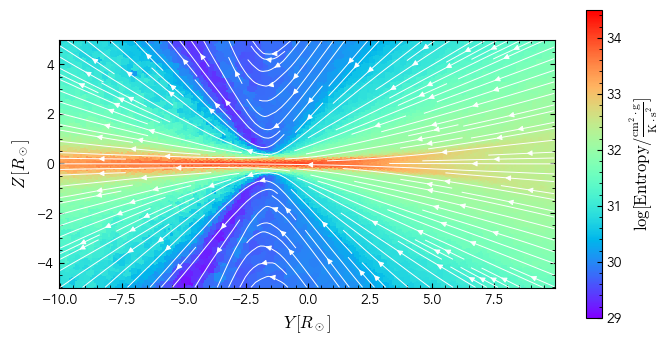

In [22]:
box = [-10, -5, 10, 5]
res = 256

# For plane="yz": grid axes are y and z; slice_coord is x.
idx, y, z = snap.to_2dgrid(
    res=res,
    plane="yz",
    box_size=box,
    slice_coord=13,
)

entropy = snap.entropy[idx].in_base("cgs")
V = snap.volume[idx].in_base("cgs")
rho = snap.density[idx].in_base("cgs")
vy = snap.vy[idx].to_value("km/s")
vz = snap.vz[idx].to_value("km/s")

fig, ax = plt.subplots(figsize=(8, 4))

richio.plots.scalar_map(
    entropy * V * rho,
    y,
    z,
    ax=ax,
    cmap="rainbow",
    label_latex=r"\mathrm{Entropy}",
)

ax.streamplot(
    y.value,
    z.value,
    vy.T,
    vz.T,
    color="white",
    density=1.5,
    linewidth=0.7,
    arrowsize=0.8,
)

ax.set_xlabel(r"$Y\,[R_\odot]$")
ax.set_ylabel(r"$Z\,[R_\odot]$")
plt.show()


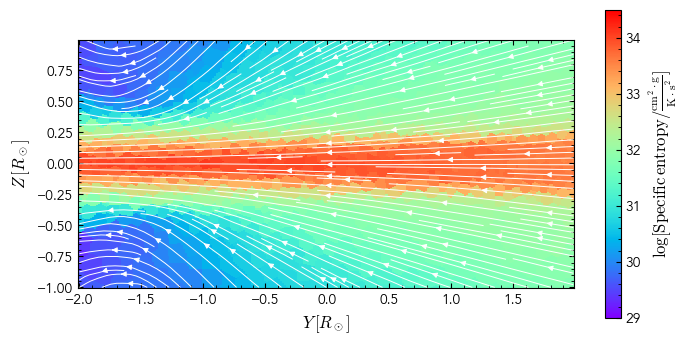

In [23]:
box = [-2, -1, 2, 1]
res = 256

# For plane="yz": grid axes are y and z; slice_coord is x.
idx, y, z = snap.to_2dgrid(
    res=res,
    plane="yz",
    box_size=box,
    slice_coord=13,
)

entropy = snap.entropy[idx].in_base("cgs")
V = snap.volume[idx].in_base("cgs")
rho = snap.density[idx].in_base("cgs")
vy = snap.vy[idx].to_value("km/s")
vz = snap.vz[idx].to_value("km/s")

fig, ax = plt.subplots(figsize=(8, 4))

richio.plots.scalar_map(
    entropy * V * rho,
    y,
    z,
    ax=ax,
    cmap="rainbow",
    label_latex=r"\mathrm{Specific\,entropy}",
)

ax.streamplot(
    y.value,
    z.value,
    vy.T,
    vz.T,
    color="white",
    density=1.5,
    linewidth=0.7,
    arrowsize=0.8,
)

ax.set_xlabel(r"$Y\,[R_\odot]$")
ax.set_ylabel(r"$Z\,[R_\odot]$")
plt.show()
